<a href="https://colab.research.google.com/github/merii26/Rice-Leaf-Disease-Detection-DL/blob/main/Bitki_Odevi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:36<00:00, 18.5MB/s]



In [4]:
!unzip -q new-plant-diseases-dataset.zip -d /content/dataset
print("3 GB'lık devasa veri başarıyla açıldı ve eğitime hazır!")

3 GB'lık devasa veri başarıyla açıldı ve eğitime hazır!


In [5]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Veri setinin bulunduğu klasör yolları
TRAIN_DIR = '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_DIR = '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

IMG_SIZE = (300, 300)
BATCH_SIZE = 32

# Eğitim verisi için çoğaltma (Augmentation) işlemleri
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Doğrulama (Validation) verisinde sadece ölçeklendirme yapılır, çoğaltma yapılmaz
valid_datagen = ImageDataGenerator(rescale=1./255)

# Verileri klasörlerden okuma
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

validation_generator = valid_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes
print(f"Harika! Toplam {NUM_CLASSES} farklı bitki/hastalık sınıfı tespit edildi.")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Harika! Toplam 38 farklı bitki/hastalık sınıfı tespit edildi.


In [6]:
# Önceden eğitilmiş temel modeli indiriyoruz
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))

# Hızlı eğitim için temel modelin mevcut bilgilerini "donduruyoruz"
for layer in base_model.layers:
    layer.trainable = False

# Kendi projemize özel katmanları ekliyoruz
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Modeli birleştirme
model = Model(inputs=base_model.input, outputs=predictions)

# Modeli derleme
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Yapay zeka modeli başarıyla kuruldu ve derlendi!")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Yapay zeka modeli başarıyla kuruldu ve derlendi!


In [9]:
from tensorflow.keras.applications import MobileNetV2

# EfficientNet yerine MobileNetV2 indiriyoruz (Çok daha hafif ve hızlı)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(300, 300, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x) # Katman boyutunu da küçülttük
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Yeni hızlı model başarıyla kuruldu!")

/tmp/ipykernel_987/3232065579.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(300, 300, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Yeni hızlı model başarıyla kuruldu!


In [10]:
# Eğitim stratejileri (Gereksiz uzamayı engeller ve en iyi ağırlıkları kaydeder)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)

print("MobileNetV2 ile hızlı eğitim başlıyor! Hız farkını şimdi göreceksin...")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr]
)

MobileNetV2 ile hızlı eğitim başlıyor! Hız farkını şimdi göreceksin...
Epoch 1/10
 943/2197 ━━━━━━━━━━━━━━━━━━━━ 1:15:41 4s/step - accuracy: 0.7014 - loss: 1.1194

KeyboardInterrupt: 

In [11]:
!kaggle datasets download -d dedeikhsandwisaputra/rice-leafs-disease-dataset
!unzip -q rice-leafs-disease-dataset.zip -d /content/rice_dataset
print("Yeni küçük veri seti başarıyla indirildi ve çıkartıldı!")

Dataset URL: https://www.kaggle.com/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset
License(s): unknown
100% 294M/294M [00:17<00:00, 17.5MB/s]

Yeni küçük veri seti başarıyla indirildi ve çıkartıldı!


In [12]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Otomatik klasör bulucu (zipten çıkan dosyanın adı farklı olursa hata vermemesi için)
base_path = '/content/rice_dataset'
TRAIN_DIR, VALID_DIR = '', ''

for root, dirs, files in os.walk(base_path):
    if 'train' in [d.lower() for d in dirs]:
        TRAIN_DIR = os.path.join(root, 'train')
    if 'validation' in [d.lower() for d in dirs] or 'valid' in [d.lower() for d in dirs]:
        VALID_DIR = os.path.join(root, 'validation') if 'validation' in dirs else os.path.join(root, 'valid')

IMG_SIZE = (128, 128) # Hız için en ideal boyut
BATCH_SIZE = 32

# Sadece ufak döndürmeler yapıyoruz
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

validation_generator = valid_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes

# MobileNetV2 Modelini Kurma
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(f"Toplam {NUM_CLASSES} sınıf için hızlı model hazır!")

Found 2100 images belonging to 6 classes.
Found 528 images belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Toplam 6 sınıf için hızlı model hazır!


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Hızlı eğitim başlıyor! Saniyeler içinde sonuç alacaksın...")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Hızlı eğitim başlıyor! Saniyeler içinde sonuç alacaksın...
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6700 - loss: 0.8325 - val_accuracy: 0.8030 - val_loss: 0.5192
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8529 - loss: 0.4029 - val_accuracy: 0.8163 - val_loss: 0.4751
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8690 - loss: 0.3463 - val_accuracy: 0.8617 - val_loss: 0.3969
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9029 - loss: 0.2756 - val_accuracy: 0.8902 - val_loss: 0.3111
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9043 - loss: 0.2500 - val_accuracy: 0.8883 - val_loss: 0.2958
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9181 - loss: 0.2362 - val_accuracy: 0.8769 - val_loss: 0.3441
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9219 - loss: 0.2158 - val_accuracy: 0.8580 - val_loss: 0.3748
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accur

In [14]:
# Modeli kaydet
model_isim = 'pirinc_hastalik_modeli.h5'
model.save(model_isim)
print(f"Model {model_isim} adıyla kaydedildi.")

# Bilgisayara indir
from google.colab import files
files.download(model_isim)

Model pirinc_hastalik_modeli.h5 adıyla kaydedildi.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# 1. Modeli yüklüyoruz (Çıkan kırmızı Warning mesajını yoksayabilirsin)
model = tf.keras.models.load_model('pirinc_hastalik_modeli.h5')

# 2. İndirdiğimiz veri setinden rastgele bir test fotoğrafı seçiyoruz
siniflar = os.listdir(VALID_DIR)
rastgele_sinif = random.choice(siniflar) # Gerçek sınıfı seç
rastgele_resim = random.choice(os.listdir(os.path.join(VALID_DIR, rastgele_sinif)))
test_resmi_yolu = os.path.join(VALID_DIR, rastgele_sinif, rastgele_resim)

print(f"--- TEST BAŞLIYOR ---")
print(f"Seçilen Yaprağın GERÇEK Durumu: {rastgele_sinif}")

# 3. Fotoğrafı 128x128 boyutuna getirip hazırlıyoruz
img = image.load_img(test_resmi_yolu, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# 4. Model tahmin yapıyor!
tahminler = model.predict(img_array, verbose=0)
tahmin_edilen_sinif_indexi = np.argmax(tahminler[0])
guven_skoru = np.max(tahminler[0])

# İndeksi isme çevirmek için sınıfları alfabetik sıralayalım
sinif_isimleri = sorted(train_generator.class_indices.keys())
tahmin_edilen_isim = sinif_isimleri[tahmin_edilen_sinif_indexi]

print(f"Modelin TAHMİNİ: {tahmin_edilen_isim}")
print(f"Modelin Kararından Emin Olma Oranı: %{guven_skoru * 100:.2f}")
print(f"---------------------")

if rastgele_sinif == tahmin_edilen_isim:
    print("✅ SONUÇ: Model doğru bildi!")
else:
    print("❌ SONUÇ: Model yanıldı.")

--- TEST BAŞLIYOR ---
Seçilen Yaprağın GERÇEK Durumu: bacterial_leaf_blight
Modelin TAHMİNİ: bacterial_leaf_blight
Modelin Kararından Emin Olma Oranı: %99.99
---------------------
✅ SONUÇ: Model doğru bildi!


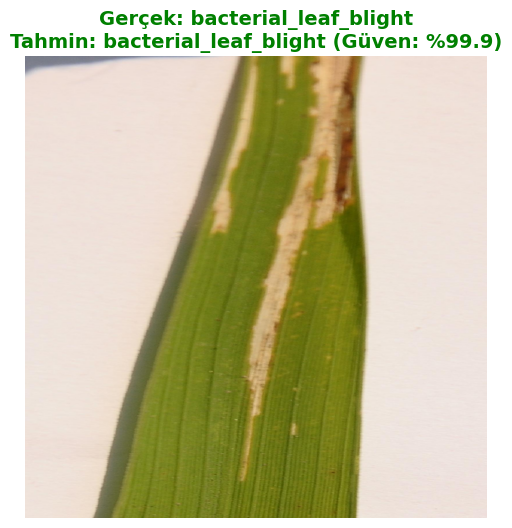

In [17]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Modeli yüklüyoruz
model = tf.keras.models.load_model('pirinc_hastalik_modeli.h5')

# 2. Rastgele bir test fotoğrafı seçiyoruz
siniflar = os.listdir(VALID_DIR)
rastgele_sinif = random.choice(siniflar)
rastgele_resim = random.choice(os.listdir(os.path.join(VALID_DIR, rastgele_sinif)))
test_resmi_yolu = os.path.join(VALID_DIR, rastgele_sinif, rastgele_resim)

# 3. Model için hazırlık
img = image.load_img(test_resmi_yolu, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# 4. Tahmin
tahminler = model.predict(img_array, verbose=0)
tahmin_edilen_sinif_indexi = np.argmax(tahminler[0])
guven_skoru = np.max(tahminler[0])

sinif_isimleri = sorted(train_generator.class_indices.keys())
tahmin_edilen_isim = sinif_isimleri[tahmin_edilen_sinif_indexi]

# --- 5. GÖRSELLEŞTİRME (Yeni Eklenen Kısım) ---
orijinal_resim = image.load_img(test_resmi_yolu) # Ekranda net görünmesi için orijinalini yüklüyoruz
plt.figure(figsize=(6, 6))
plt.imshow(orijinal_resim)

# Başlık metnini hazırlama
baslik_metni = f"Gerçek: {rastgele_sinif}\nTahmin: {tahmin_edilen_isim} (Güven: %{guven_skoru*100:.1f})"

# Doğru bildiyse Yeşil, yanlış bildiyse Kırmızı renkli başlık
if rastgele_sinif == tahmin_edilen_isim:
    plt.title(baslik_metni, color='green', fontsize=14, fontweight='bold')
else:
    plt.title(baslik_metni, color='red', fontsize=14, fontweight='bold')

plt.axis('off') # Kenardaki gereksiz koordinat çizgilerini gizle
plt.show()